In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import yfinance as yf

In [27]:
df = yf.Ticker("TSLA").history(period="1y")

# Calculate 20-day moving average and standard deviation
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["STD_20"] = df["Close"].rolling(window=20).std()

# Calculate Bollinger Bands
df["Upper_Band"] = df["SMA_20"] + (df["STD_20"] * 2)
df["Lower_Band"] = df["SMA_20"] - (df["STD_20"] * 2)

# Band Width (indicates volatility)
df["Band_Width"] = df["Upper_Band"] - df["Lower_Band"]
df


,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,STD_20,Upper_Band,Lower_Band,Band_Width
Date,,,,,,,,,,,,
2024-03-12 00:00:00-04:00,177.770004,179.429993,172.410004,177.539993,87391700,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2024-03-13 00:00:00-04:00,173.050003,176.050003,169.149994,169.479996,106524500,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2024-03-14 00:00:00-04:00,167.770004,171.169998,160.509995,162.500000,126325700,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2024-03-15 00:00:00-04:00,163.160004,165.179993,160.759995,163.570007,96971900,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2024-03-18 00:00:00-04:00,170.020004,174.720001,165.899994,173.800003,108214400,0.0,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-05 00:00:00-05:00,272.920013,279.549988,267.709991,279.100006,94042900,0.0,0.0,329.167500,34.958449,399.084398,259.250603,139.833795
2025-03-06 00:00:00-05:00,272.059998,272.649994,260.019989,263.450012,98451600,0.0,0.0,323.431500,35.894053,395.219606,251.643394,143.576212
2025-03-07 00:00:00-05:00,259.320007,266.250000,250.729996,262.670013,102369600,0.0,0.0,317.849001,36.243555,390.336110,245.361891,144.974219


In [28]:
# Identify breakouts (price moving significantly above/below Bollinger Bands)
df["Breakout"] = ((df["Close"] > df["Upper_Band"]) | (df["Close"] < df["Lower_Band"])).astype(int)

# Identify consolidation (low Bollinger Band width)
df["Consolidation"] = (df["Band_Width"] < df["Band_Width"].rolling(window=10).mean() * 0.8).astype(int)

# Final Label: 1 for Breakout, 0 for Consolidation
df["Target"] = (df["Breakout"] == 1).astype(int)

In [29]:
# Select features
features = ["Band_Width", "Close", "Volume"]
X = df[features].dropna()
y = df["Target"].loc[X.index]  # Ensure matching index
print(len(X))
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

# Train a simple RandomForest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

231
Accuracy: 0.85


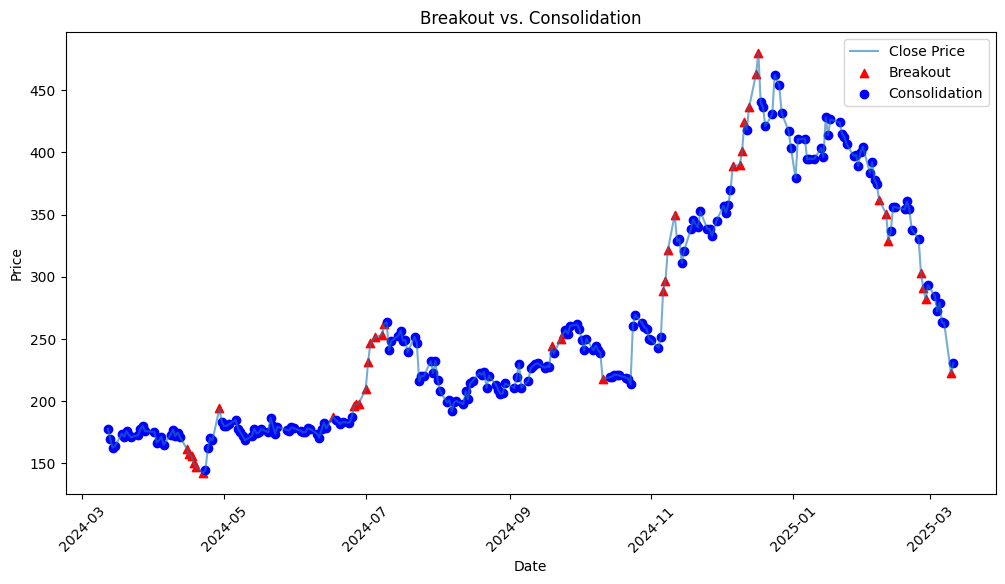

In [30]:
plt.figure(figsize=(12,6))

# Plot the close price
plt.plot(df.index, df["Close"], label="Close Price", alpha=0.6)

# Scatter plot for breakouts
plt.scatter(df.index[df["Target"] == 1], df["Close"][df["Target"] == 1],
            color="red", label="Breakout", marker="^")

# Scatter plot for consolidations
plt.scatter(df.index[df["Target"] == 0], df["Close"][df["Target"] == 0],
            color="blue", label="Consolidation", marker="o")

# Add labels and title
plt.legend()
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Breakout vs. Consolidation")

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

plt.show()
